In [40]:
from sqlalchemy import create_engine

USERNAME = "prerana"
PASSWORD = "Prerana123$"
HOST = "localhost"
PORT = "5432"
DATABASE = "bank_analytics"

engine = create_engine(
    f"postgresql://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

print("Connected successfully!")

Connected successfully!


In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/prerana/Documents/Banking_case/Banking_clean.csv")

df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [44]:
product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Business Lending",
    "Foreign Currency Account",
    "Saving Accounts",
    "Checking Accounts"
]
df["Total_Financial_Value"] = (
    df["Superannuation Savings"] +
    df["Bank Deposits"] +
    df["Saving Accounts"] +
    df["Checking Accounts"] +
    df["Foreign Currency Account"] +
    df["Business Lending"] +
    df["Bank Loans"]
)

# Combine income + assets into one value metric
df["Customer_Value"] = df["Estimated Income"] + df["Total_Financial_Value"]

#RFM-Style Engagement Matrix

# Convert "Joined Bank" to datetime
df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], errors="coerce")

# Calculate recency as "years since joining"
today = pd.to_datetime("today")
df["Recency_Years"] = ((today - df["Joined Bank"]).dt.days) / 365

rfm_product_cols = [
    "Superannuation Savings",
    "Bank Loans",
    "Bank Deposits",
    "Checking Accounts",
    "Saving Accounts",
    "Foreign Currency Account",
    "Business Lending"
]
# F: Frequency
# Count number of products actively used
df["Frequency"] = df[rfm_product_cols].gt(0).sum(axis=1)

#  M: Monetary
df["Monetary"] = df["Estimated Income"]
#Filling missing NaN with median
df.isnull().sum().sort_values(ascending=False)
#Numerical:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
#Categorical:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
y_reg = df["Customer_Value"]

current_year = 2026

df["Joined Bank"] = pd.to_datetime(
    df["Joined Bank"],
    errors="coerce"
)

df["Tenure"] = (
    current_year - df["Joined Bank"].dt.year
)

df["Tenure"] = df["Tenure"].fillna(
    df["Tenure"].median()
)

# Debt-to-Income Ratio
df["Debt_Income_Ratio"] = (
    df["Bank Loans"] /
    (df["Estimated Income"] + 1)
)

# Credit Utilization
df["Credit_Utilization"] = (
    df["Credit Card Balance"] /
    (df["Amount of Credit Cards"] + 1)
)df.to_sql(
    "bank_customers",
    engine,
    if_exists="replace",
    index=False
)

print("Updated SQL table uploaded!")


df["value_segment"] = pd.qcut(
    df["Customer_Value"],
    q=3,
    labels=["Low", "Medium", "High"]
)


In [45]:
df.to_sql(
    "bank_customers",
    engine,
    if_exists="replace",
    index=False
)

print("Updated SQL table uploaded!")

Updated SQL table uploaded!


In [46]:
#Clean column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

print(df.columns)

Index(['client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'total_financial_value',
       'customer_value', 'recency_years', 'frequency', 'monetary', 'tenure',
       'debt_income_ratio', 'credit_utilization', 'value_segment'],
      dtype='object')


In [47]:
#Upload data to PostgreSQL
df.to_sql(
    "bank_customers",
    engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!


In [48]:
query = """
SELECT
    occupation,
    AVG(customer_value) AS avg_customer_value
FROM bank_customers
GROUP BY occupation
ORDER BY avg_customer_value DESC;
"""

result = pd.read_sql(query, engine)

result.head()

,occupation,avg_customer_value
0,General Manager,4.422364e+06
1,Food Chemist,4.103392e+06
2,Office Assistant III,4.016885e+06
3,Software Engineer IV,4.002883e+06
4,Web Developer IV,3.992060e+06


In [49]:
#Executive KPIs
#Total customers
query = """
SELECT COUNT(*) AS total_customers
FROM bank_customers;
"""

pd.read_sql(query, engine)

,total_customers
0,3000


In [50]:
#Average Customer value
query = """
SELECT AVG(customer_value) AS avg_customer_value
FROM bank_customers;
"""

pd.read_sql(query, engine)

,avg_customer_value
0,2.910428e+06


In [51]:
#Total deposits
query = """
SELECT SUM(bank_deposits) AS total_deposits
FROM bank_customers;
"""

pd.read_sql(query, engine)

,total_deposits
0,2.014681e+09


In [52]:
#Customer profitability analysis - Highest value occupations
query = """
SELECT
    occupation,
    AVG(customer_value) AS avg_customer_value,
    COUNT(*) AS customers
FROM bank_customers
GROUP BY occupation
ORDER BY avg_customer_value DESC;
"""

occupation_analysis = pd.read_sql(query, engine)

occupation_analysis.head()

,occupation,avg_customer_value,customers
0,General Manager,4.422364e+06,16
1,Food Chemist,4.103392e+06,9
2,Office Assistant III,4.016885e+06,19
3,Software Engineer IV,4.002883e+06,15
4,Web Developer IV,3.992060e+06,12


In [53]:
#Risk Analysis - High risk customers
query = """
SELECT
    client_id,
    occupation,
    risk_weighting,
    bank_loans,
    customer_value
FROM bank_customers
WHERE risk_weighting > 70
ORDER BY bank_loans DESC;
"""

high_risk = pd.read_sql(query, engine)

high_risk.head()

,client_id,occupation,risk_weighting,bank_loans,customer_value


In [56]:
#Loyalty analysis
query = """
SELECT
    loyalty_classification,
    AVG(customer_value) AS avg_value,
    AVG(risk_weighting) AS avg_risk
FROM bank_customers
GROUP BY loyalty_classification
ORDER BY avg_value DESC;
"""

pd.read_sql(query, engine)

,loyalty_classification,avg_value,avg_risk
0,Jade,2.974801e+06,2.259204
1,Silver,2.894414e+06,2.242503
2,Gold,2.880342e+06,2.247863
3,Platinum,2.734406e+06,2.227129


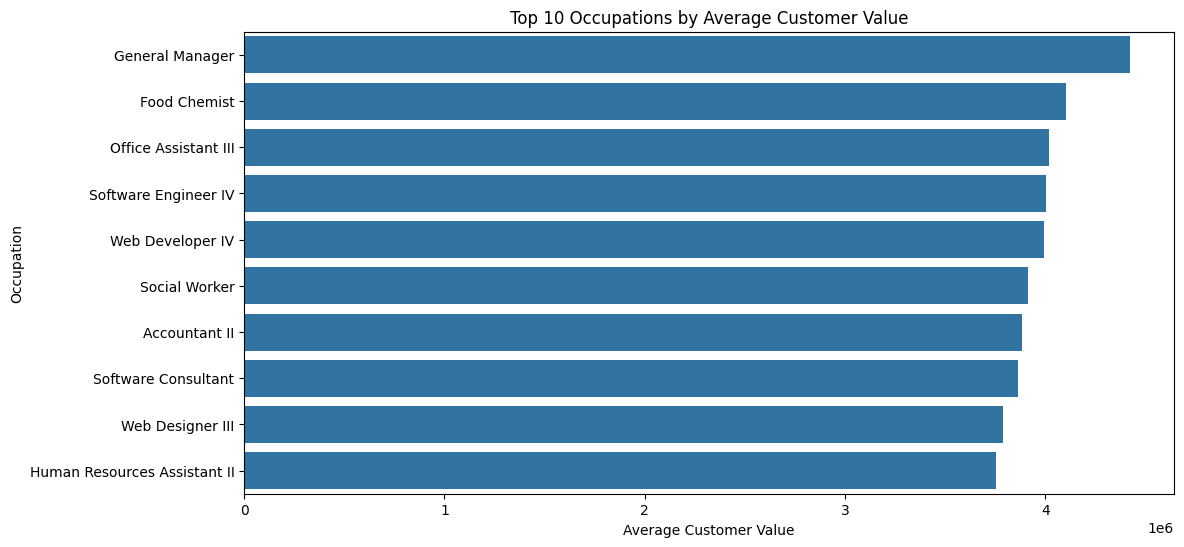

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_occupations = result.head(10)

sns.barplot(
    data=top_occupations,
    x="avg_customer_value",
    y="occupation"
)

plt.title("Top 10 Occupations by Average Customer Value")
plt.xlabel("Average Customer Value")
plt.ylabel("Occupation")

plt.show()